In [1]:
analysis_year = 2024
metro_rel_path = "Data/Metro/서울교통공사_역별 시간대별 승하차인원(24.1~24.12) (1).csv"

In [2]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / metro_rel_path).exists() and (project_root.parent / metro_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [3]:
metro_path = project_root / metro_rel_path
subway_df = pd.read_csv(metro_path, encoding="cp949")

station_col = "역명"
direction_col = "승하차구분" if "승하차구분" in subway_df.columns else "구분"
date_col = "수송일자" if "수송일자" in subway_df.columns else "날짜"

selected_stations = ["여의도", "여의나루"]
time_order = [
    "06시이전", "06시 이전", "06-07시간대", "06시-07시", "07-08시간대", "07시-08시",
    "08-09시간대", "08시-09시", "09-10시간대", "09시-10시", "10-11시간대", "10시-11시",
    "11-12시간대", "11시-12시", "12-13시간대", "12시-13시", "13-14시간대", "13시-14시",
    "14-15시간대", "14시-15시", "15-16시간대", "15시-16시", "16-17시간대", "16시-17시",
    "17-18시간대", "17시-18시", "18-19시간대", "18시-19시", "19-20시간대", "19시-20시",
    "20-21시간대", "20시-21시", "21-22시간대", "21시-22시", "22-23시간대", "22시-23시",
    "23-24시간대", "23시-24시", "24시이후", "24시 이후"
]
hour_cols = [col for col in time_order if col in subway_df.columns]

filtered_df = subway_df[subway_df[station_col].isin(selected_stations)].copy()
filtered_df[date_col] = pd.to_datetime(filtered_df[date_col])
filtered_df["날짜타입"] = filtered_df[date_col].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")
cleaned_df = filtered_df[[station_col, date_col, "날짜타입", direction_col] + hour_cols].copy()
display(cleaned_df.head())


,역명,날짜,날짜타입,구분,06시 이전,06시-07시,07시-08시,08시-09시,09시-10시,10시-11시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시 이후
270,여의도,2024-01-01,평일,승차,67,62,106,123,105,113,...,443,481,548,498,398,346,339,232,40,2
271,여의도,2024-01-01,평일,하차,42,172,175,333,301,290,...,440,549,469,286,209,173,122,100,62,31
272,여의나루,2024-01-01,평일,승차,41,76,102,469,133,88,...,440,463,504,419,339,316,291,228,77,0
273,여의나루,2024-01-01,평일,하차,39,286,467,157,284,251,...,468,448,420,340,242,179,125,117,57,3
814,여의도,2024-01-02,평일,승차,80,132,417,602,411,365,...,1346,1891,6340,8422,3123,2329,1785,1017,384,55


In [4]:
station_avg_df = (
    cleaned_df
    .groupby([station_col, "날짜타입", direction_col], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=[station_col, "날짜타입", direction_col],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
time_order_map = {column: idx for idx, column in enumerate(hour_cols)}
median_df["시간_순서"] = median_df["시간"].map(time_order_map)
median_df = (
    median_df
    .groupby(["날짜타입", direction_col, "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", direction_col, "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,역명,날짜타입,구분,06시 이전,06시-07시,07시-08시,08시-09시,09시-10시,10시-11시,11시-12시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시 이후
0,여의나루,주말,승차,44.067308,70.951923,75.625000,138.403846,153.865385,292.163462,370.442308,...,946.480769,1252.250000,1412.096154,1489.596154,1500.259615,1812.913462,1470.971154,1081.836538,363.144231,1.759615
1,여의나루,주말,하차,38.855769,212.932692,348.182692,565.471154,599.625000,940.211538,1120.298077,...,1879.576923,1793.019231,1681.971154,1241.538462,858.567308,515.663462,334.480769,194.326923,107.461538,10.730769
2,여의나루,평일,승차,43.248092,104.988550,265.183206,408.087786,227.316794,189.446565,250.236641,...,723.450382,984.751908,2220.500000,2727.041985,1239.351145,1320.889313,1073.187023,771.339695,303.114504,42.427481
3,여의나루,평일,하차,50.202290,410.538168,1891.900763,3125.717557,1221.370229,713.839695,637.442748,...,769.454198,800.679389,992.576336,1198.572519,714.011450,423.171756,283.301527,205.026718,98.748092,45.916031
4,여의도,주말,승차,69.692308,85.086538,124.038462,195.826923,239.038462,323.875000,441.384615,...,1156.346154,1456.278846,1503.384615,1424.817308,1281.163462,1550.221154,1120.519231,634.884615,146.528846,1.548077


,날짜타입,구분,시간,시간_순서,중앙값
0,주말,승차,06시 이전,0,56.879808
1,주말,승차,06시-07시,1,78.019231
2,주말,승차,07시-08시,2,99.831731
3,주말,승차,08시-09시,3,167.115385
4,주말,승차,09시-10시,4,196.451923


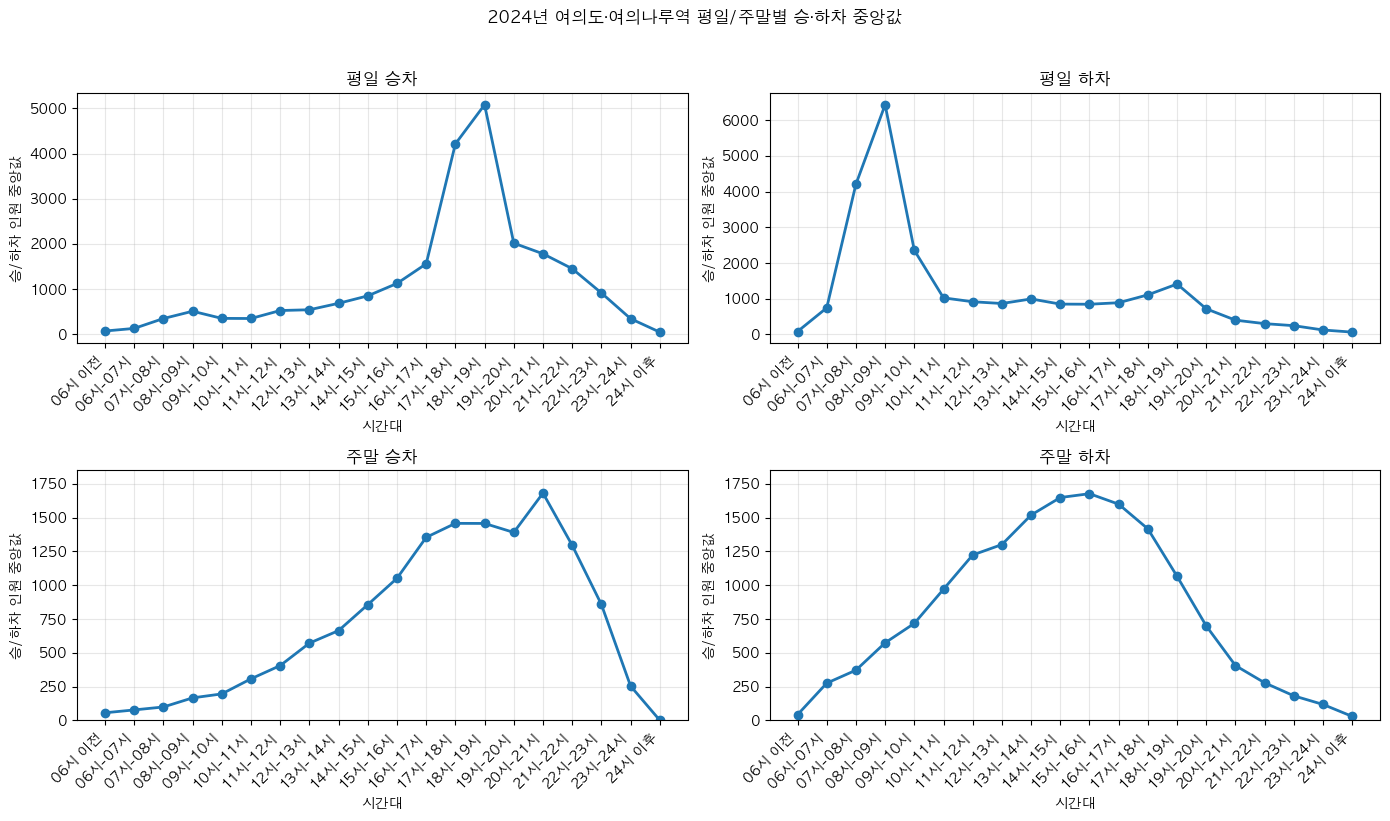

In [5]:
plot_order = [("평일", "승차"), ("평일", "하차"), ("주말", "승차"), ("주말", "하차")]
weekend_max = median_df[median_df["날짜타입"] == "주말"]["중앙값"].max()
weekend_ymax = weekend_max * 1.1 if pd.notna(weekend_max) else None

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

for ax, (date_type, direction) in zip(axes.flatten(), plot_order):
    subset = median_df[(median_df["날짜타입"] == date_type) & (median_df[direction_col] == direction)].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(f"{date_type} {direction}")
    ax.set_xlabel("시간대")
    ax.set_ylabel("승/하차 인원 중앙값")
    ax.set_xticks(range(len(hour_cols)))
    ax.set_xticklabels(hour_cols, rotation=45, ha="right")
    if date_type == "주말" and weekend_ymax is not None:
        ax.set_ylim(0, weekend_ymax)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 여의도·여의나루역 평일/주말별 승·하차 중앙값", y=1.02)
fig.tight_layout()
plt.show()


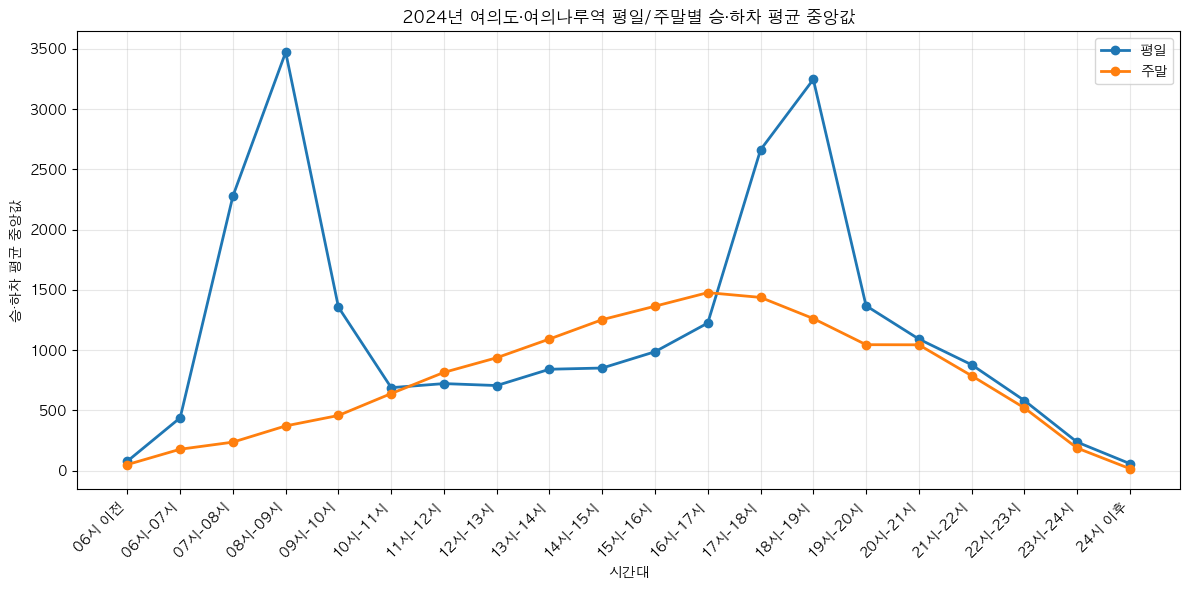

In [6]:
# Combined Weekday/Weekend Summary
combined_station_avg_df = (
    station_avg_df
    .groupby([station_col, "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

combined_median_df = combined_station_avg_df.melt(
    id_vars=[station_col, "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
combined_median_df["시간_순서"] = combined_median_df["시간"].map(time_order_map)
combined_median_df = (
    combined_median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
for date_type, color in [("평일", "#1f77b4"), ("주말", "#ff7f0e")]:
    subset = combined_median_df[combined_median_df["날짜타입"] == date_type].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2, label=date_type, color=color)

ax.set_title(f"{analysis_year}년 여의도·여의나루역 평일/주말별 승·하차 평균 중앙값")
ax.set_xlabel("시간대")
ax.set_ylabel("승·하차 평균 중앙값")
ax.set_xticks(range(len(hour_cols)))
ax.set_xticklabels(hour_cols, rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
